# Tutorial 1: Stochastically Solving a Spatially Heterogeneous Bimolecular System #

## Introduction ##
In this tutorial, we will extend the spatially homogeneous model of the bimolecular reaction network to include spatial heterogeneities. In doing so, we will generate an idealized cell architecture with extracellular, plasma membrane, and cytosol regions. We will then use Lattice Microbes to solve for (spatially-resolved) system trajectories for each chemical species. Below is a description of the chemical system we will be using:

$$
A + B \xrightarrow{k_f} C
$$

$$
C \xrightarrow{k_r} A + B
$$

## Set the Working Directory and Import Packages ##
To solve this system, we will import functionalities from numpy, scipy and matplotlib as well as the general operating system package (os) to enable us to access various standard file commands. But first, we will use a predefined function to set our working directory.

In [1]:
# Import necessary packages #
import os, sys

# Define function to find desired working directory #
def _find_tutorial_dir(notebook_filename):
    """Locate this notebook's directory by searching upward from CWD."""
    start = os.path.abspath(os.getcwd())
    search = start
    for _ in range(8):
        if os.path.isfile(os.path.join(search, notebook_filename)):
            return search
        for subdir in ['LM/RDME/Tutorial01_BimolecularReactions',
                       'RDME/Tutorial01_BimolecularReactions',
                       'Tutorial01_BimolecularReactions']:
            candidate = os.path.abspath(os.path.join(search, subdir))
            if os.path.isfile(os.path.join(candidate, notebook_filename)):
                return candidate
        search = os.path.dirname(search)
    return None

# Define desired working directory #
_here = _find_tutorial_dir('TutR1.1_bimolecular_uni.ipynb')
if _here is None:
    raise RuntimeError(
        "Cannot locate Tutorial01_BimolecularReactions/. "
        "Please ensure the repository structure is intact."
    )

# Set working directory #
os.chdir(_here)
print(f"Working directory set to:\n{_here}")

Working directory set to:
/data/GitHub_Repos/SummerSchool_2026/LM/RDME/Tutorial01_BimolecularReactions


Next, we will import other necessary packages and a custom script for plotting our results.

In [2]:
# Import standard python libraries #
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import jLM packages and modules #
import jLM                                  # Set up the Jupyter environment
from jLM.RegionBuilder import RegionBuilder # Deal with the spatial geometry
from jLM.RDME import Sim as RDMESim         # Main simulation class
from lm import IntMpdRdmeSolver             # lm::rdme::IntMpdRdmeSolver
from jLM.RDME import File as RDMEFile       # Functionality for working with RDME output files

## Define the RDME Simulation Object ##

We begin by creating an **`RDME.Sim`** python object that we call `sim`. We have imported this to simply be able to be called using `RDMESim`, so we will use this syntax in our actual code. This object will hold all information necessary to run the stochastic spatially-heterogeneous simulation.

The class we use here is:

``` python
sim = jLM.RDME.Sim(simulation_name, 
                   filename, 
                   dimensions, 
                   latticeSpacing, 
                   regionName, 
                   dt)
````
+ `simulation_name` (*String*): the name of our system;
+ `filename` (*String*): the name of the final output trajectory file which is saved in hdf5 format;
+ `dimensions` (*3D List*): the number of voxels for our simulation in the x, y, and z dimensions, supplied as a list (each dimension integer must be divisible by 32);
+ `latticeSpacing` (*Float*): the side length of the each voxel in meters;
+ `regionName` (*String*): the name of the default region type that is applied to every voxel at initialization (default="external");
+ `lattice_type` (*String*): Either "Int" (allows ~4 million chemical species) or "Byte" (allows 255 chemical species) specifying how particles are stored in each lattice, and dictating which solver the user must use during the simulation (`IntMpdRdmeSolver` or `MpdRdmeSolver`, respectively);
+ `dt` (*Float*): the length of the time step for the RDME simualtion in seconds

In [3]:
# Define simulation and system parameters #              
# Define simulation name #
simname = "RDME_Bimolecular"
# Define output file name #
filename = "TutR1.1_bimolecular_uni.lm"
# Define number of voxels in each dimension #
Ldim = [64,64,64]
# Define length of each voxel edge (m) #
lattice_spacing = 16.625e-9           
# Define name of default region type #
regionN = "extracellular"
# Define lattice_type as "Int" #
lattice_type = "Int"
# Define timestep to be used in simulation (s) #
dt = 25e-6                         

# Construct RDME simulation object #
sim = RDMESim(simname, 
              filename, 
              Ldim, 
              lattice_spacing, 
              regionN,
              lattice_type,
              dt)

In case you forget, or want to redefine some key parameters in the simulation after creating the simulation object, you can always use the following methods to adjust them:

In [4]:
# Redefine simulation timestep #
sim.timestep = 50e-6            # in s

Next, we define the total simulation time, the the lattice write interval, and the species write interval. The write intervals should be supplied as integers and are in units of "timesteps". The biological time between write intervals would be: 

$$
t_{Biological} = WriteInterval * dt
$$

Because we defined $dt = 50 \times 10^{-6} s$, the actual write interval would be:

$$
0.1s = 2000 * 50 \times 10^{-6}s
$$


In [5]:
# Define the total simulation time (s) #
sim.simulationTime = 30.0
# Define the lattice write interval (timesteps) #
sim.latticeWriteInterval = int(2000)
# Define the species write interval (timesteps) #
sim.speciesWriteInterval = int(2000)

## Create the System Architecture ##
Now that we have our simulation object created, we will construct the system geometry/architecture. For the system in this tutorial, we will have three region types:
+ `extracellular`,
+ `cytoplasm`, and
+ `membrane`

In order to design the site lattice geometry, we create a `RegionBuilder` object, which can read the lattice dimensions from our simulation object `sim`. For a detailed description of the functions and methods contained in `RegionBuilder`, see [RegionBuilderCheatSheet.md](../RegionBuilderCheatSheet.md).

In [6]:
# Create RegionBuilder object to define system architecture #
build = RegionBuilder(sim)

First, we will build our cytosol region mask. To do so, we will create a sphere with a radius of 400nm, centered at voxel site [32,32,32]. When we build regions, we most often know the actual physical lengths/sizes rather than the sizes in voxels, but Lattice Microbes requires that our input be in voxels. Therefore, we must convert between the two using the following formula:

```math
Voxels = ActualLength / LatticeSpacing
```

In [ ]:
# Define actual radius/length (m) #
radius_actual = 400e-9
# Convert radius to voxels #
radius_voxel = int(np.ceil(radius_actual / lattice_spacing))
# Define boolean mask for cytosol region type using ellipsoid method #
cytosol_mask = build.ellipsoid(radius = radius_voxel)
# Print number of voxels for the cytosol radius #
print(f"Cytosol radius in voxels: ", {radius_voxel})

Cytosol radius in voxels:  {25}


Next, we want to create our plasma membrane mask. To do so, we will dilate the cytosol mask with the dilation method (see [RegionBuilderCheatSheet.md](../RegionBuilderCheatSheet.md)). Doing so will create a mask with a sphere that is larger than our cytosol and is filled in. This will be a problem is we add the membrane after the cytosol when building our final mask, because the membrane region will completely overwrite our cytosol region. We could avoid this by ensuring that our cytosol region is added after the membrane region, but to be safe, we will set all sites that are true in the cytosol region to be false in the plasma membrane region as well. This will ensure that the order these regions are added  does not affect the final simulation architecture.

In [8]:
# Create dialated mask from cytosol input #
# Use SE26 (ensures all membrane regions are connected) #
cytosol_dilation_mask = build.dilate(cytosol_mask, se = build.se26)
# Remove cytosol regions from membrane mask #
membrane_mask = cytosol_dilation_mask & ~cytosol_mask

Finally, although our extracellular region was already defined as all voxels by default, we want to exclude all voxels from the extracellular mask that will be assigned to another region. Again, if the extracellular region is composed first, this will not matter, but just to be safe, we will perform this operation so no errors will be made.

In [9]:
# Exclude all cellular region types from the extracellular region type mask #
extracellular_mask = ~cytosol_dilation_mask

After building all region-specific masks, we must now create an region type object from the `sim.region` method for all masks. Finally, we will pass all region type objects and their accompanying region type mask to the `build.compose` function. This will add our final site lattice to the RDME simulation object.

In [10]:
# Create region type objects for each mask #
# Cytosol #
cyt = sim.region('cytosol')
# Plasma membrane #
mem = sim.region('membrane')
# Extracellular #
ext = sim.region('extracellular')

# Build our final lattice and save it to our simulation object #
build.compose(
    # Arbitrary number of lists with two elements each: #
    # (Region type, region mask) #
      (ext,         extracellular_mask),
      (cyt,         cytosol_mask),
      (mem,         membrane_mask))

Now, let's visualize the final lattice architecture!

In [11]:
# Show 2D slices of final lattice architecture #
sim.showRegionStack()

In [ ]:
# Show interactive 3D final lattice architecture #
sim.displayGeometry()

## Define Chemical Species, Initial Abundances, and Initial Positions ##
Now that we are satisfied with our system architecture, we will begin to define our system's chemical species and reaction network. Similar to the spatially homogeneous systems, we will use a function called `sim.species` to create objects which will represent each chemical species in our system. After doing this, we will add our initial species abundances and locations using the `distributeNumber` function. This function will, by default, distribute a given number of the defined species uniformly and randomly throughout the chosen region. Here, we choose to place 1000 molecules of species A and species B in the cytosol.

In [13]:
# Create chemical species objects #
# Species A #
spA = sim.species('A')
# Species B #
spB = sim.species('B')
# Species C #
spC = sim.species('C')

# Place initial abundance of each chemical species in predetermined initial locations within simulation object #
# 1000 of species A in the cytosol #
sim.distributeNumber(spA, cyt, 1000)
# 1000 of species B in the cytosol #
sim.distributeNumber(spB, cyt, 1000)
# 0 of species C in the cytosol #
sim.distributeNumber(spC, cyt, 0)

## Define the Chemical Reaction Network of the System ##
Next, and in a similar fashion to the spatially homogeneous systems, we will construct our chemical reaction network. The RDME simulation object expects rates for chemical reactions to be given in concentration-based units:

| Reaction order | Example | Units for rate value |
|---|---|---|
| 0th order | $\emptyset \rightarrow A$ | M / s |
| 1st order | $C \rightarrow A + B$ | s⁻¹ |
| 2nd order | $A + B \rightarrow C$ | M⁻¹ s⁻¹ |

jLM automatically converts these macroscopic rate constants into the stochastic rate constants required by the RDME solver using the following equation:

$$
k_{\text{stochastic}} = k_{\text{det}} \cdot \left( N_A \cdot V_{\text{voxel}} \right)^{1 - \text{order}}
$$

where $N_A$ is Avogadro's number and $V_{\text{voxel}}$ is the voxel volume in liters. This means you never need to divide by $N_A$ or the volume yourself.

Rate constants are created using the `sim.rateConst` function and stored in the simulation object using the following syntax:

``` python
sim.rateConst(rate, value, order)
```
+ `rate` (*String*): a name for the rate constant, used to retrieve it later as `sim.rc.<rate>`;
+ `value` (*Float*): the numerical value of the rate constant in standard chemical kinetics units (see table above);
+ `order` (*Int*): the order of the reaction this constant belongs to (`1` = first order, `2` = second order);

After calling `sim.rateConst`, the returned `RateConst` object is both stored in `sim.rc.<name>` and returned directly, so you can save it as a local variable for convenience.

In [14]:
# Define rate constants #
# Forward reaction, second-order #  
kf = sim.rateConst('kf', 1.07e5, 2)  
# Reverse reaction, first-order #  
kr = sim.rateConst('kr', 0.351 , 1)   

With rate constants defined, reactions are added to specific regions using `addReaction`. This method is called on a `Region` object — either retrieved on the fly via `sim.region('name')` or from a previously created region variable. This is what restricts a given reaction to occur only in that region. The function signature is:

``` python
region.addReaction(reactants, products, rate, value=None)
```
+ `reactants` (*list of Species objects or* `[]`): the species consumed by the reaction; pass an empty list `[]` for a zeroth-order reaction with no reactants;
+ `products` (*list of Species objects or* `[]`): the species produced by the reaction; pass an empty list `[]` to model pure degradation;
+ `rate` (*RateConst object or str*): the rate constant for the reaction; typically either the `RateConst` object returned directly by `sim.rateConst()`, or the same object accessed later via `sim.rc.<name>`; if a string is passed, `value` must also be provided;
+ `value` (*Float, optional*): if `rate` is provided as a string name rather than a `RateConst` object, supplying `value` will create a new `RateConst` with that name and value on the fly;

**Note:** all reactants, products, and rate constants must be jLM objects, not plain numbers or strings. A reaction added to one region will not occur in any other region unless `addReaction` is called again on that region.

In [15]:
# Add forward reaction to simulation object #
cyt.addReaction([spA,spB], [spC], kf)
# Add reverse reaction to simulation object #
cyt.addReaction([spC], [spA,spB], kr)

## Set Diffusion Coefficients for Each Chemical Species ##
After specifying the chemical reaction network for our system, we will need to define the diffusion coefficients for each species. This must be done using all combinations of region transitions. For example, for species A, we will need to define the following diffusion coefficients:
* Extracellular to extracellular
* Extracellular to membrane
* Extracellular to cytosol
* Membrane to extracellular
* Membrane to membrane
* Membrane to cytosol
* Cytosol to extracellular
* Cytosol to membrane
* Cytosol to cytosol

However, because almost all of the diffusion rates between the above regions will be not allowed in our current system, we will start by setting all diffusion coefficients to zero. To do this, we will use the `transitionRate` function. This function accepts arguments as follows:

``` python
sim.transitionRate(sp, rFrom, rTo, rate, value=None)
```
+ `sp` (*Species object or* `None`): the chemical species to set the diffusion rate for; passing `None` acts as a wildcard and applies the rate to **all** species;
+ `rFrom` (*Region object or* `None`): the source region from which the species is diffusing; passing `None` applies the rate to **all** source regions;
+ `rTo` (*Region object or* `None`): the destination region into which the species is diffusing; passing `None` applies the rate to **all** destination regions;
+ `rate` (*DiffusionConst object*): a `DiffusionConst` object specifying the diffusion coefficient to assign (e.g. `sim.diffusionZero` or a previously defined coefficient via `sim.dc.<name>`);
+ `value` (*Float, optional*): if `rate` is provided as a string name rather than a `DiffusionConst` object, supplying `value` will create a new `DiffusionConst` with that name and value on the fly.

`sim.diffusionZero` is a built-in diffusion coefficient equal to 0.

In [16]:
# Initialize all diffusion coefficients for all species across all region types to be zero #
sim.transitionRate(None, None, None, sim.diffusionZero)

Next, we want to make it possible for our species to diffuse within the cytosol, so we will create a new diffusion coefficient object using the `diffusionConst` function. We supply a name (string) and a value (float) for the coefficient in $m^{2}/s$. This object is stored in the simulation object as `sim.dc.<name>` with `<name>` being the user-supplied name of the diffusion coefficient.

In [17]:
# Create diffusion coefficient within simulation object called "diff1" at 0.01 um2/s = 1e-14 m2/s #
sim.diffusionConst('diff1', 1e-14)

After defining a diffusion coefficient, we will assign transitions from the cytosol to the cytosol for each species in our simulation object.

In [18]:
# Call the user-defined diffusion coefficient and set all cytosol-cytosol transitions to this coefficient value #
# Species A #
sim.transitionRate(spA, cyt, cyt, sim.dc.diff1)
# Species B #
sim.transitionRate(spB, cyt, cyt, sim.dc.diff1)
# Species C #
sim.transitionRate(spC, cyt, cyt, sim.dc.diff1)

# Can also be done in a single command using the following syntax #
sim.transitionRate(None, cyt, cyt, sim.dc.diff1)

Finally, now that we have all chemical species, initial abundances, chemical reactions, reaction rate constants, and diffusion coefficients defined, we can check our system and simulation specifications before performing the simulation.

In [19]:
# Check all species, abundances, chemical reactions, and diffusion coefficients #
sim.showAllSpecies()

Time step,50.000 µs
Simulation time,30.000 s
Lattice write interval,2.000 × 103 s
Particle count write interval,2.000 × 103 s
Dimensions,64 × 64 × 64
Particles per site,16
Bytes per particle,4
Lattice spacing,16.625 nm
Subvolume size,4.595 × 10-6 fl
Output file,TutR1.1_bimolecular_uni.lm
Number of species,3

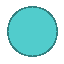

In [20]:
# Check all system and simulation parameters #
sim

## Run the RDME Simulation ##
Now, we will run our `finalize` function to tell the simulation object that we are ready to perform a simluation and then run the simulation with the `sim.run` function. The `sim.run` function syntax is as follows:

``` python
sim.run(solver=None, replicate=1, seed=None, cudaDevices=None,
        checkpointInterval=0, sample_frame=False, max_frames=100)
```
+ `solver` (*RDMESolver object, optional*): the solver instance to use; for a `"Int"` lattice type use `IntMpdRdmeSolver()`, for `"Byte"` use `MpdRdmeSolver()`; defaults to `MpdRdmeSolver()` if not specified;
+ `replicate` (*Int, optional*): replicate index written into the output file; useful when running multiple independent trajectories into the same `.lm` file (default: `1`);
+ `seed` (*Int, optional*): integer seed for the random number generator; if not provided, a time-based seed is used automatically, giving a different trajectory each run;
+ `cudaDevices` (*list of Int, optional*): list of CUDA GPU device indices to run on (e.g. `[0]` for the first GPU, `[0, 1]` for two GPUs); defaults to `[0]`;
+ `checkpointInterval` (*Int, optional*): number of seconds between saving checkpoints to disk during the run; `0` disables checkpointing (default: `0`);
+ `sample_frame` (*Bool, optional*): if `True`, frames are subsampled when the result file is loaded back; useful for very long trajectories (default: `False`);
+ `max_frames` (*Int, optional*): maximum number of frames to retain when `sample_frame=True` (default: `100`);

nodiffregion in finalize: [0, 2]
2026-06-22 21:27:13) Info: Using 32 processor(s) and 1 CUDA device(s) per process.
2026-06-22 21:27:13) Info: Assigning 1.00 processor(s) and 1.00 CUDA device(s) per replicate.
2026-06-22 21:27:13) Info: Data output thread running.
2026-06-22 21:28:13) Info: Wrote 230 data sets (3858769110 bytes) in the last 60.06 seconds (6.34 seconds writing). 0 datasets queued. Flushing.
2026-06-22 21:28:13) Info: Average walltime per timestep: 0.13 ms. Progress: 23.1018s/30.0000s ( 77% done / 18 seconds walltime remaining)
2026-06-22 21:28:32) Info: Data output thread finished.
2026-06-22 21:28:32) Info: Simulation file closed.



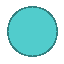

In [21]:
# Finalize the simulation state #
sim.finalize()
# Run the RDME simulation #
sim.run(solver=IntMpdRdmeSolver(), cudaDevices=[0])

An important note about the RDME solver in Lattice Microbes is that, by default, it performs a single simulation replicate, which is stored as the first replicate in the output file. If additional replicates are desired, one must specify the replicate that is being run so that previous simulations are not overwritten.

## Analysis of Simulation Data ##
Congratulations, you have run your first RDME simulation in LM!

The output of this simulation is saved as a `.lm` file, which is in h5 format. We can use the `RDME.File` function which we have imported as `RDMEFile` to import our species trajectories into our python session. In this function, we will use the `getNumberTrajectory` method to extract out each species trajectory. This method uses the following syntax:

``` python
ts, counts = traj.getNumberTrajectory(species=None, regex=None, replicate=None,
                                       frameStart=None, frameEnd=None,
                                       timeStart=None, timeEnd=None)
```
+ `species` (*Species object, str, or list, optional*): the species to retrieve; can be a `Species` object, a species name string, or a list of either — if a list is given, the counts of all listed species are summed into a single trajectory; mutually exclusive with `regex`;
+ `regex` (*str, optional*): a regular expression matched against species names; all matching species counts are summed; mutually exclusive with `species`;
+ `replicate` (*Int, optional*): which simulation replicate to read from; defaults to the current replicate in the file;
+ `frameStart` (*Int, optional*): index of the first frame to return (inclusive); if omitted, starts from the beginning;
+ `frameEnd` (*Int, optional*): index of the last frame to return (exclusive); if omitted, reads to the end;
+ `timeStart` (*Float, optional*): simulation time (in seconds) of the first frame to return; alternative to `frameStart`;
+ `timeEnd` (*Float, optional*): simulation time (in seconds) of the last frame to return; alternative to `frameEnd`;

The method returns two `numpy` arrays: `ts` (evaluation times in seconds, shape `(nt,)`) and `counts` (particle counts, shape `(nt,)`).

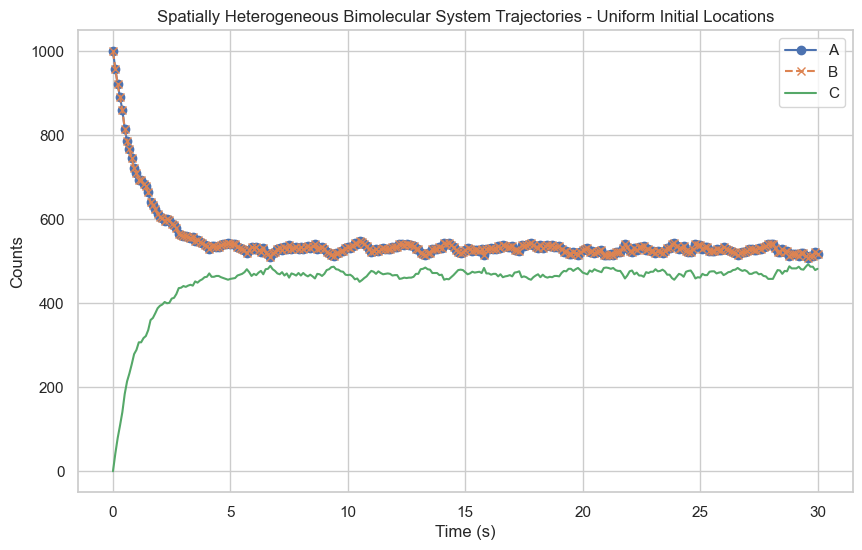

In [22]:
# Read in RDME simulation output file as object named traj #
traj = RDMEFile(filename)
# Define timepoint array and species abundance arrays #
ts, As = traj.getNumberTrajectory(species="A")
ts, Bs = traj.getNumberTrajectory(species="B")
ts, Cs = traj.getNumberTrajectory(species="C")

# Visualize the species trajectories #
sns.set(style="whitegrid")
palette = sns.color_palette()  
plt.figure(figsize=(10,6))
plt.plot(ts, As, label='A',marker='o', linestyle='-',color=palette[0])
plt.plot(ts, Bs, label='B',marker='x', linestyle='--',color=palette[1])
plt.plot(ts, Cs, label='C',color=palette[2])
plt.title('Spatially Heterogeneous Bimolecular System Trajectories - Uniform Initial Locations')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.legend()
plt.savefig('./Plots/RDME_Bimolecular_Uniform.png')
plt.show()

Alternatively, we could have used the python package `h5py` to access the species trajectories, or we could have downloaded [`HDFView`](https://www.hdfgroup.org/downloads/) to explore the output file in a GUI.